# RQ2: Home Repeatability in Stroke Participants Only

**Research Question 2:** After identifying valid IMU-derived features in the laboratory, can the same feature set be extracted consistently from repeated unsupervised smartphone recordings in the home environment?

This notebook uses the first three weeks of home recordings for each SRS participant and reports ICC(3,1), a two-way mixed-effects, single-measure consistency ICC.


In [1]:
from pathlib import Path
import json
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 80)
pd.set_option("display.precision", 3)
warnings.filterwarnings("ignore", category=RuntimeWarning)

PROJECT_ROOT = Path("..").resolve() if Path.cwd().name == "Sensors_Visualizers" else Path.cwd()
SUBJECTS_JSON = PROJECT_ROOT / "subjects.json"
FEATURE_ROOT = PROJECT_ROOT

MIN_RECORDINGS_PER_SUBJECT = 3
HOME_WINDOW_DAYS = 21
HOME_WEEK_COUNT = 3

PRIMARY_FEATURES = {
    "walk": ["walk_duration", "step_count", "walk_protocol_cadence", "walk_protocol_mean_step_time"],
    "left_turn": ["left_turn_duration", "left_turn_step_count", "left_turn_peak_angular_velocity"],
    "right_turn": ["right_turn_duration", "right_turn_step_count", "right_turn_peak_angular_velocity"],
    "sit_to_stand": ["sit_to_stand_duration", "sit_to_stand_time_to_peak_acc", "sit_to_stand_peak_acc", "sit_to_stand_peak_gyro"],
    "stand_to_sit": ["stand_to_sit_duration", "stand_to_sit_time_to_peak_acc", "stand_to_sit_peak_acc", "stand_to_sit_peak_gyro"],
}

FEATURE_LABELS = {
    "walk_duration": "Walk duration (s)",
    "step_count": "Walking step count",
    "cadence": "Walking cadence (steps/min)",
    "mean_step_time": "Walking mean step time (s)",
    "walk_10_step_duration": "Walking 10-step duration (s)",
    "walk_10_step_cadence": "Walking 10-step cadence (steps/min)",
    "walk_10_step_mean_step_time": "Walking 10-step mean step time (s)",
    "walk_protocol_cadence": "Walking protocol cadence (steps/min)",
    "walk_protocol_mean_step_time": "Walking protocol mean step time (s)",
    "left_turn_duration": "Left turn duration (s)",
    "left_turn_step_count": "Left turn step count",
    "left_turn_peak_angular_velocity": "Left turn peak angular velocity",
    "right_turn_duration": "Right turn duration (s)",
    "right_turn_step_count": "Right turn step count",
    "right_turn_peak_angular_velocity": "Right turn peak angular velocity",
    "sit_to_stand_duration": "Sit-to-stand duration (s)",
    "sit_to_stand_time_to_peak_acc": "Sit-to-stand time to peak acc (s)",
    "sit_to_stand_peak_acc": "Sit-to-stand peak acc",
    "sit_to_stand_peak_gyro": "Sit-to-stand peak gyro",
    "stand_to_sit_duration": "Stand-to-sit duration (s)",
    "stand_to_sit_time_to_peak_acc": "Stand-to-sit time to peak acc (s)",
    "stand_to_sit_peak_acc": "Stand-to-sit peak acc",
    "stand_to_sit_peak_gyro": "Stand-to-sit peak gyro",
}

all_features = [f for group in PRIMARY_FEATURES.values() for f in group]
print("Project root:", PROJECT_ROOT)


Project root: /Users/ahmed/Documents/CSULB/Research/MyWalkSentinel


## Load Home Features and Keep SRS Stroke Participants Only

Rows are included only when `patient_id` maps through `subjects.json` to an `SRS...` participant. The repeatability analysis uses the first 21 days after each participant's first home recording for each participant.


In [2]:
def load_subject_map(path=SUBJECTS_JSON):
    with open(path, "r") as f:
        srs_to_patient = json.load(f)
    patient_to_srs = {f"patient_{patient_id}": srs_id for srs_id, patient_id in srs_to_patient.items()}
    return srs_to_patient, patient_to_srs


def load_home_features(root=FEATURE_ROOT):
    frames = []
    skipped = []
    for path in sorted(root.glob("features_dataset_*.csv")):
        try:
            df = pd.read_csv(path)
        except Exception as exc:
            skipped.append({"file": path.name, "reason": str(exc)})
            continue
        if df.empty:
            skipped.append({"file": path.name, "reason": "empty"})
            continue
        frames.append(df.copy())
    return (pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()), pd.DataFrame(skipped)


def keep_first_three_weeks(df, days=HOME_WINDOW_DAYS):
    out = df.copy()
    first_date = out.groupby("subject_id")["date"].transform("min")
    out["home_day"] = (out["date"] - first_date).dt.days + 1
    out = out[out["home_day"].between(1, days)].copy()
    out["home_week"] = ((out["home_day"] - 1) // 7 + 1).astype(int)
    out = out[out["home_week"].between(1, HOME_WEEK_COUNT)].copy()
    return out.sort_values(["subject_id", "date"]).reset_index(drop=True)

srs_to_patient, patient_to_srs = load_subject_map()
home_raw, skipped_files = load_home_features()

home_all = home_raw.copy()
home_all["patient_id"] = home_all["patient_id"].astype(str)
home_all["subject_id"] = home_all["patient_id"].map(patient_to_srs)
home_all["date"] = pd.to_datetime(home_all["date"], errors="coerce")

home = home_all[home_all["subject_id"].notna() & home_all["subject_id"].astype(str).str.startswith("SRS")].copy()
home = home.sort_values(["subject_id", "date"]).reset_index(drop=True)
home_3week = keep_first_three_weeks(home)

load_summary = pd.DataFrame([{
    "total_loaded_rows": len(home_all),
    "srs_rows_before_three_week_filter": len(home),
    "srs_rows_first_three_weeks": len(home_3week),
    "excluded_unmapped_or_non_srs_rows": int(home_all["subject_id"].isna().sum()),
    "srs_participants_first_three_weeks": home_3week["subject_id"].nunique(),
}])
display(load_summary)


,total_loaded_rows,srs_rows_before_three_week_filter,srs_rows_first_three_weeks,excluded_unmapped_or_non_srs_rows,srs_participants_first_three_weeks
0,510,498,154,12,17


## Home Recording Summary

This plot is kept as the main data-coverage check. Counts reflect only recordings inside the first three weeks for each SRS participant.


,srs_subjects,home_recordings_first_3_weeks,median_recordings_per_subject,min_recordings_per_subject,max_recordings_per_subject
0,17,154,10.0,1,18


,subject_id,n_recordings,n_days,n_weeks,followup_days
3,SRS03,18,18,3,20
0,SRS001,17,17,3,16
12,SRS15,17,17,3,18
5,SRS05,15,15,3,20
14,SRS17,15,15,3,20
8,SRS11,13,13,3,20
4,SRS04,13,13,3,18
6,SRS08,11,11,3,19
10,SRS13,10,10,3,15
7,SRS09,9,9,3,15


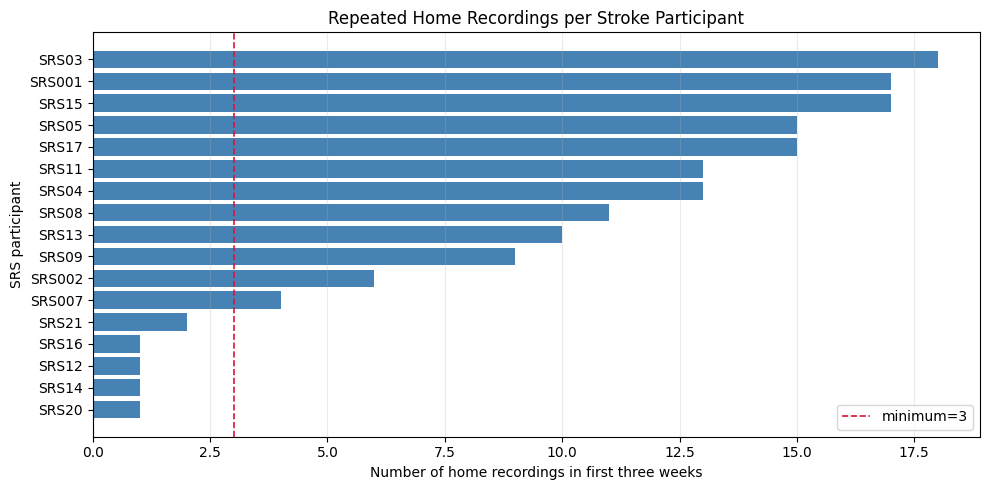

In [3]:
recording_counts = (
    home_3week.groupby(["subject_id", "patient_id"], as_index=False)
    .agg(
        n_recordings=("date", "count"),
        first_date=("date", "min"),
        last_date=("date", "max"),
        n_days=("date", "nunique"),
        n_weeks=("home_week", "nunique"),
    )
    .sort_values("n_recordings", ascending=False)
)
recording_counts["followup_days"] = (recording_counts["last_date"] - recording_counts["first_date"]).dt.days

summary_counts = pd.DataFrame([{
    "srs_subjects": home_3week["subject_id"].nunique(),
    "home_recordings_first_3_weeks": len(home_3week),
    "median_recordings_per_subject": recording_counts["n_recordings"].median(),
    "min_recordings_per_subject": recording_counts["n_recordings"].min(),
    "max_recordings_per_subject": recording_counts["n_recordings"].max(),
}])
display(summary_counts)
display(recording_counts[["subject_id", "n_recordings", "n_days", "n_weeks", "followup_days"]].head(10))

fig, ax = plt.subplots(figsize=(10, 5))
plot_df = recording_counts.sort_values("n_recordings", ascending=True)
ax.barh(plot_df["subject_id"], plot_df["n_recordings"], color="steelblue")
ax.axvline(MIN_RECORDINGS_PER_SUBJECT, color="crimson", linestyle="--", linewidth=1.2, label=f"minimum={MIN_RECORDINGS_PER_SUBJECT}")
ax.set_xlabel("Number of home recordings in first three weeks")
ax.set_ylabel("SRS participant")
ax.set_title("Repeated Home Recordings per Stroke Participant")
ax.grid(axis="x", alpha=0.25)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


## Feature Table Preparation


In [4]:
rows = []
for activity, features in PRIMARY_FEATURES.items():
    for feature in features:
        if feature not in home_3week.columns:
            continue
        rows.append(pd.DataFrame({
            "subject_id": home_3week["subject_id"],
            "patient_id": home_3week["patient_id"],
            "date": home_3week["date"],
            "home_day": home_3week["home_day"],
            "home_week": home_3week["home_week"],
            "activity": activity,
            "feature": feature,
            "feature_label": FEATURE_LABELS.get(feature, feature),
            "value": pd.to_numeric(home_3week[feature], errors="coerce"),
        }))

home_long = pd.concat(rows, ignore_index=True).dropna(subset=["value", "date"])
print(f"Prepared {len(home_long):,} feature rows from the first three weeks.")


Prepared 2,662 feature rows from the first three weeks.


## Feature Availability


In [5]:
availability = (
    home_long.groupby(["activity", "feature", "feature_label"], as_index=False)
    .agg(available_n=("value", "count"), n_subjects=("subject_id", "nunique"))
)
availability["available_percent_of_rows"] = (availability["available_n"] / len(home_3week) * 100).round(1)
availability = availability.sort_values("available_percent_of_rows", ascending=False)
display(availability[["activity", "feature_label", "n_subjects", "available_n", "available_percent_of_rows"]])


,activity,feature_label,n_subjects,available_n,available_percent_of_rows
0,left_turn,Left turn duration (s),16,150,97.4
2,left_turn,Left turn step count,16,150,97.4
13,stand_to_sit,Stand-to-sit time to peak acc (s),17,150,97.4
12,stand_to_sit,Stand-to-sit peak gyro,17,150,97.4
11,stand_to_sit,Stand-to-sit peak acc,17,150,97.4
10,stand_to_sit,Stand-to-sit duration (s),17,150,97.4
1,left_turn,Left turn peak angular velocity,16,150,97.4
8,sit_to_stand,Sit-to-stand peak gyro,17,148,96.1
9,sit_to_stand,Sit-to-stand time to peak acc (s),17,148,96.1
7,sit_to_stand,Sit-to-stand peak acc,17,148,96.1


## Walking Cadence Consistency Check

This diagnostic verifies whether the stored cadence values agree with the walking step count and duration. It is not used to filter the data.


In [6]:
cadence_check = home_3week.copy()
for col in ["walk_duration", "step_count", "cadence"]:
    cadence_check[col] = pd.to_numeric(cadence_check[col], errors="coerce")

cadence_check["expected_cadence"] = cadence_check["step_count"] / cadence_check["walk_duration"].replace(0, np.nan) * 60.0
cadence_check["cadence_error"] = cadence_check["cadence"] - cadence_check["expected_cadence"]

cadence_diagnostic = pd.DataFrame([{
    "walking_rows_checked": int(cadence_check["cadence_error"].notna().sum()),
    "mean_abs_cadence_formula_error": float(cadence_check["cadence_error"].abs().mean()),
    "max_abs_cadence_formula_error": float(cadence_check["cadence_error"].abs().max()),
}]).round(3)
display(cadence_diagnostic)


,walking_rows_checked,mean_abs_cadence_formula_error,max_abs_cadence_formula_error
0,144,0.0,0.0


## ICC(3,1) Repeatability Metrics

Home repeatability is assessed without Vicon because home recordings have no motion-capture reference. For ICC(3,1), each participant is represented by up to three weekly feature estimates from the first three weeks. If a participant completed multiple recordings in the same week, those recordings are averaged within that week before ICC is calculated.


In [7]:
def icc_3_1_from_wide(wide):
    """Two-way mixed-effects, single-measure, consistency ICC: ICC(3,1)."""
    wide = wide.dropna(axis=0, how="any")
    n, k = wide.shape
    if n < 2 or k < 2:
        return np.nan
    values = wide.to_numpy(dtype=float)
    grand = np.nanmean(values)
    row_means = np.nanmean(values, axis=1, keepdims=True)
    col_means = np.nanmean(values, axis=0, keepdims=True)
    ss_rows = k * np.sum((row_means - grand) ** 2)
    ss_error = np.sum((values - row_means - col_means + grand) ** 2)
    ms_rows = ss_rows / (n - 1)
    ms_error = ss_error / ((n - 1) * (k - 1))
    denom = ms_rows + (k - 1) * ms_error
    return float((ms_rows - ms_error) / denom) if denom > 0 else np.nan


def build_weekly_feature_table(long_df):
    return (
        long_df.groupby(["activity", "feature", "feature_label", "subject_id", "home_week"], as_index=False)["value"]
        .mean()
    )


def build_icc_summary(long_df):
    weekly = build_weekly_feature_table(long_df)
    rows = []
    for (activity, feature, label), g in weekly.groupby(["activity", "feature", "feature_label"]):
        wide = g.pivot_table(index="subject_id", columns="home_week", values="value", aggfunc="mean")
        wide = wide.reindex(columns=list(range(1, HOME_WEEK_COUNT + 1)))
        complete = wide.dropna(axis=0, how="any")
        if complete.empty:
            continue
        per_subject = complete.agg(["count", "mean", "std"], axis=1)
        per_subject["cv_percent"] = per_subject["std"] / per_subject["mean"].abs().replace(0, np.nan) * 100
        week_changes = complete.diff(axis=1).abs().to_numpy().ravel()
        rows.append({
            "activity": activity,
            "feature": feature,
            "feature_label": label,
            "n_subjects": int(complete.shape[0]),
            "n_weekly_measurements": int(complete.notna().sum().sum()),
            "mean_value": float(complete.to_numpy().mean()),
            "sd_all_weeks": float(np.nanstd(complete.to_numpy().ravel(), ddof=1)),
            "median_cv_percent": float(per_subject["cv_percent"].replace([np.inf, -np.inf], np.nan).median()),
            "iqr_cv_percent": float(per_subject["cv_percent"].replace([np.inf, -np.inf], np.nan).quantile(.75) - per_subject["cv_percent"].replace([np.inf, -np.inf], np.nan).quantile(.25)),
            "icc_3_1": icc_3_1_from_wide(complete),
            "median_abs_week_to_week_change": float(np.nanmedian(week_changes)) if len(week_changes) else np.nan,
        })
    out = pd.DataFrame(rows)
    for col in out.select_dtypes(include=[np.number]).columns:
        out[col] = out[col].round(3)
    return out.sort_values("icc_3_1", ascending=False).reset_index(drop=True)

weekly_home_long = build_weekly_feature_table(home_long)
repeatability_summary = build_icc_summary(home_long)
display(repeatability_summary)


,activity,feature,feature_label,n_subjects,n_weekly_measurements,mean_value,sd_all_weeks,median_cv_percent,iqr_cv_percent,icc_3_1,median_abs_week_to_week_change
0,walk,walk_protocol_mean_step_time,Walking protocol mean step time (s),11,33,1.544,0.875,11.284,8.621,0.926,0.223
1,walk,step_count,Walking step count,11,33,24.659,9.103,11.319,6.650,0.877,3.654
2,walk,walk_protocol_cadence,Walking protocol cadence (steps/min),11,33,49.318,18.206,11.319,6.650,0.877,7.307
3,right_turn,right_turn_step_count,Right turn step count,12,36,10.975,3.448,9.658,8.734,0.840,1.050
4,left_turn,left_turn_step_count,Left turn step count,12,36,10.966,3.228,10.277,10.293,0.821,1.325
5,walk,walk_duration,Walk duration (s),11,33,18.867,7.564,13.192,10.180,0.812,2.177
6,left_turn,left_turn_duration,Left turn duration (s),12,36,7.616,1.818,8.044,10.405,0.807,0.807
7,right_turn,right_turn_duration,Right turn duration (s),12,36,7.531,2.053,7.083,6.135,0.807,0.344
8,sit_to_stand,sit_to_stand_time_to_peak_acc,Sit-to-stand time to peak acc (s),11,33,1.641,1.439,29.938,20.610,0.796,0.385
9,sit_to_stand,sit_to_stand_duration,Sit-to-stand duration (s),11,33,3.228,2.857,18.129,14.153,0.790,0.401


## Repeatability Summary Table

This table combines the repeatability metric and supporting variability measures in one place. `ICC(3,1)` is the main RQ2 statistic.


In [8]:
repeatability_table = repeatability_summary[[
    "activity",
    "feature_label",
    "n_subjects",
    "n_weekly_measurements",
    "median_cv_percent",
    "median_abs_week_to_week_change",
    "icc_3_1",
]].copy()

repeatability_table = repeatability_table.rename(columns={
    "activity": "Activity",
    "feature_label": "Feature",
    "n_subjects": "Subjects",
    "n_weekly_measurements": "Weekly measurements",
    "median_cv_percent": "Median CV (%)",
    "median_abs_week_to_week_change": "Median week-to-week change",
    "icc_3_1": "ICC(3,1)",
})

repeatability_table = repeatability_table.sort_values("ICC(3,1)", ascending=False).reset_index(drop=True)
display(repeatability_table)


,Activity,Feature,Subjects,Weekly measurements,Median CV (%),Median week-to-week change,"ICC(3,1)"
0,walk,Walking protocol mean step time (s),11,33,11.284,0.223,0.926
1,walk,Walking step count,11,33,11.319,3.654,0.877
2,walk,Walking protocol cadence (steps/min),11,33,11.319,7.307,0.877
3,right_turn,Right turn step count,12,36,9.658,1.050,0.840
4,left_turn,Left turn step count,12,36,10.277,1.325,0.821
5,walk,Walk duration (s),11,33,13.192,2.177,0.812
6,left_turn,Left turn duration (s),12,36,8.044,0.807,0.807
7,right_turn,Right turn duration (s),12,36,7.083,0.344,0.807
8,sit_to_stand,Sit-to-stand time to peak acc (s),11,33,29.938,0.385,0.796
9,sit_to_stand,Sit-to-stand duration (s),11,33,18.129,0.401,0.790


## Home Repeatability by Feature

Use this plot as the main visual answer for RQ2. Features are sorted from lower to higher ICC(3,1). The vertical lines mark weak, moderate, and strong repeatability zones.


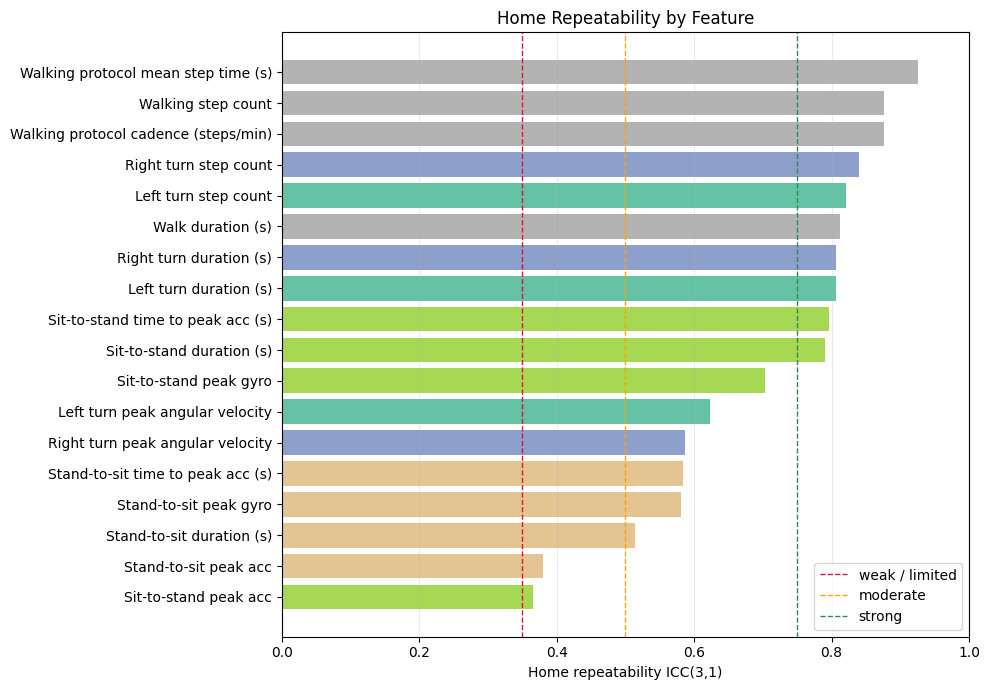

In [9]:
feature_plot = repeatability_summary.dropna(subset=["icc_3_1"]).copy()
feature_plot = feature_plot[feature_plot["n_subjects"] >= 2]
feature_plot = feature_plot.sort_values("icc_3_1", ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
activity_codes = feature_plot["activity"].astype("category").cat.codes
colors = plt.cm.Set2(activity_codes / max(activity_codes.max(), 1))

ax.barh(feature_plot["feature_label"], feature_plot["icc_3_1"], color=colors)
ax.axvline(0.35, color="crimson", linestyle="--", linewidth=1, label="weak / limited")
ax.axvline(0.50, color="orange", linestyle="--", linewidth=1, label="moderate")
ax.axvline(0.75, color="seagreen", linestyle="--", linewidth=1, label="strong")
ax.set_xlabel("Home repeatability ICC(3,1)")
ax.set_title("Home Repeatability by Feature")
ax.set_xlim(0, 1)
ax.grid(axis="x", alpha=0.25)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


## Final RQ2 Summary


In [10]:
compact_final = repeatability_table.copy()
display(compact_final)

print("RQ2 short answer, SRS stroke participants only, first three weeks, ICC(3,1):")
strong_features = compact_final[compact_final["ICC(3,1)"] >= 0.75]
moderate_features = compact_final[(compact_final["ICC(3,1)"] >= 0.50) & (compact_final["ICC(3,1)"] < 0.75)]
print("Strong features (ICC >= 0.75):")
print(", ".join(strong_features["Feature"].tolist()) if len(strong_features) else "None")
print("Moderate features (0.50 <= ICC < 0.75):")
print(", ".join(moderate_features["Feature"].tolist()) if len(moderate_features) else "None")


,Activity,Feature,Subjects,Weekly measurements,Median CV (%),Median week-to-week change,"ICC(3,1)"
0,walk,Walking protocol mean step time (s),11,33,11.284,0.223,0.926
1,walk,Walking step count,11,33,11.319,3.654,0.877
2,walk,Walking protocol cadence (steps/min),11,33,11.319,7.307,0.877
3,right_turn,Right turn step count,12,36,9.658,1.050,0.840
4,left_turn,Left turn step count,12,36,10.277,1.325,0.821
5,walk,Walk duration (s),11,33,13.192,2.177,0.812
6,left_turn,Left turn duration (s),12,36,8.044,0.807,0.807
7,right_turn,Right turn duration (s),12,36,7.083,0.344,0.807
8,sit_to_stand,Sit-to-stand time to peak acc (s),11,33,29.938,0.385,0.796
9,sit_to_stand,Sit-to-stand duration (s),11,33,18.129,0.401,0.790


RQ2 short answer, SRS stroke participants only, first three weeks, ICC(3,1):
Strong features (ICC >= 0.75):
Walking protocol mean step time (s), Walking step count, Walking protocol cadence (steps/min), Right turn step count, Left turn step count, Walk duration (s), Left turn duration (s), Right turn duration (s), Sit-to-stand time to peak acc (s), Sit-to-stand duration (s)
Moderate features (0.50 <= ICC < 0.75):
Sit-to-stand peak gyro, Left turn peak angular velocity, Right turn peak angular velocity, Stand-to-sit time to peak acc (s), Stand-to-sit peak gyro, Stand-to-sit duration (s)


## Subject-Level Boxplots

Use these boxplots as a secondary visual check. They show whether each SRS participant has a stable personal range for selected home features across the first three weeks.


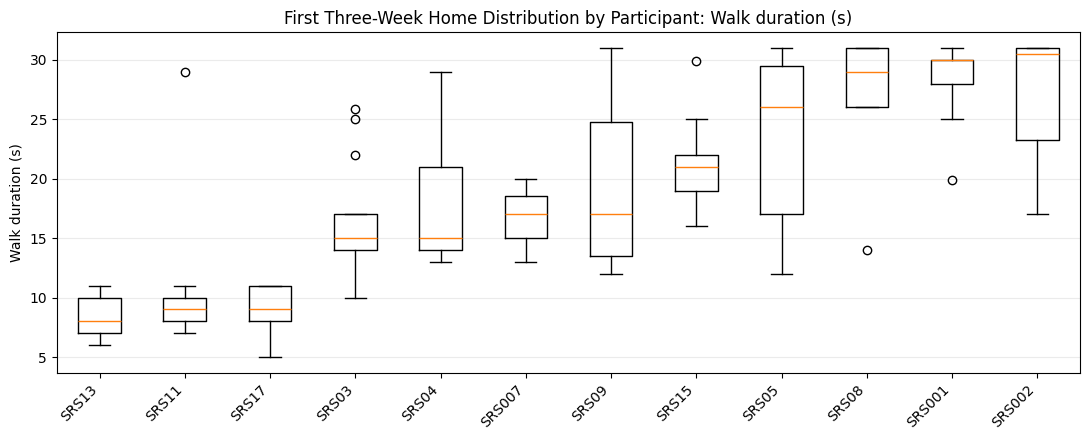

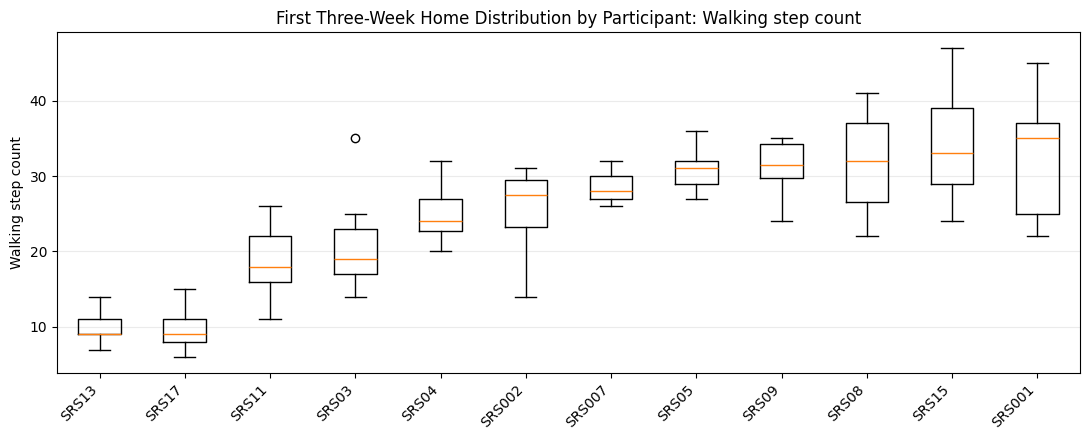

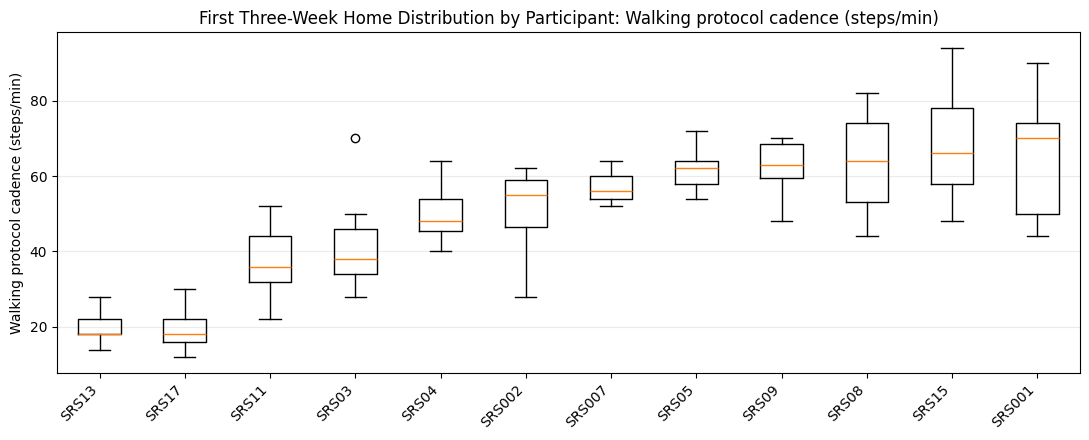

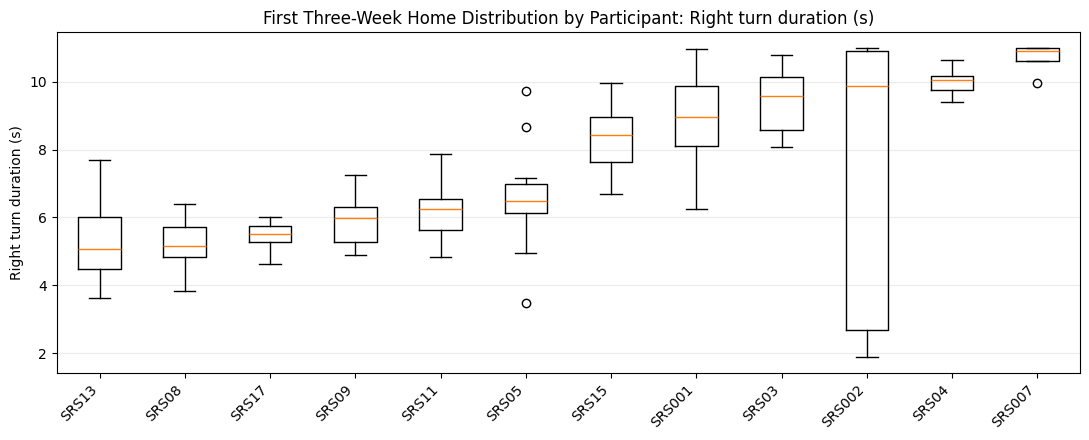

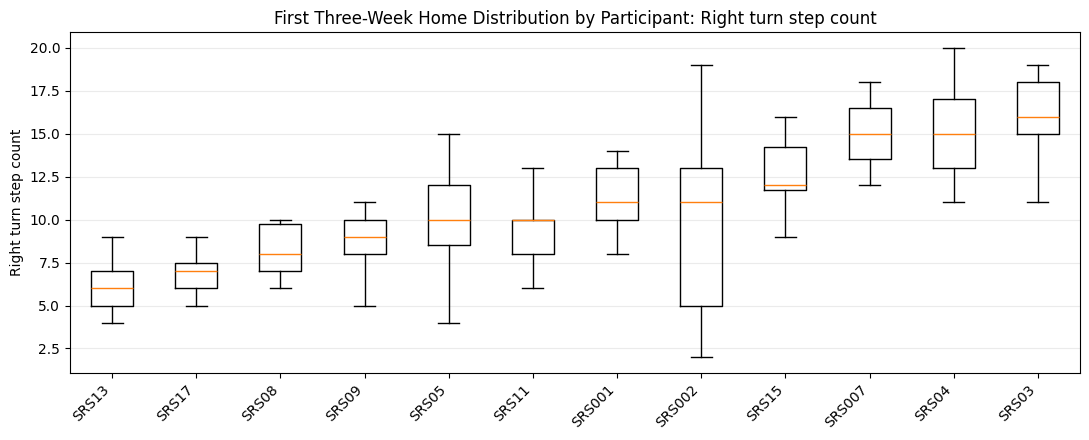

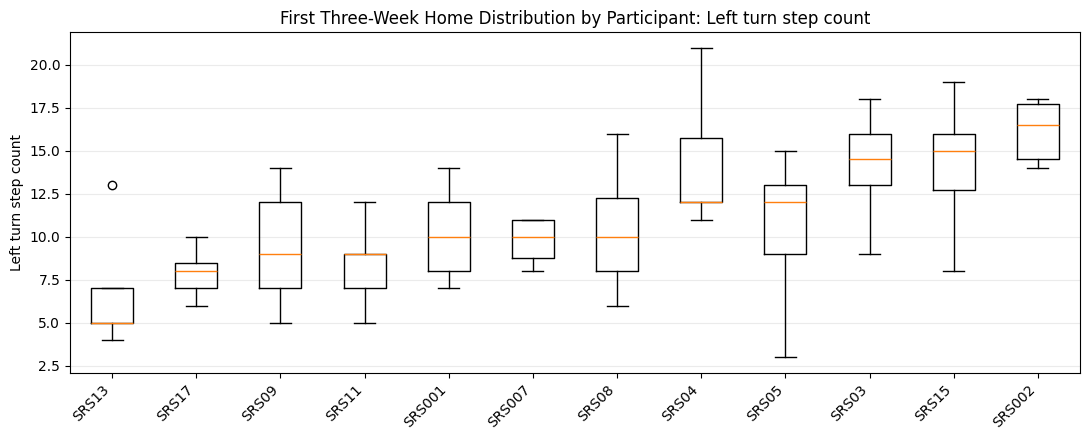

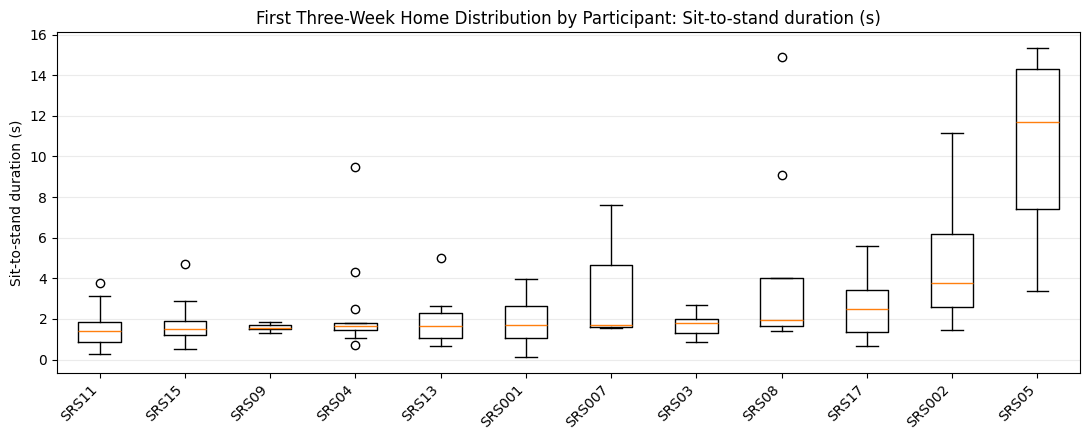

In [11]:
BOXPLOT_FEATURES = [
    "walk_duration",
    "step_count",
    "walk_protocol_cadence",
    "right_turn_duration",
    "right_turn_step_count",
    "left_turn_step_count",
    "sit_to_stand_duration",
]

for feature in BOXPLOT_FEATURES:
    data = home_long[home_long["feature"].eq(feature)].copy()
    counts = data.groupby("subject_id")["value"].count()
    keep = counts[counts >= MIN_RECORDINGS_PER_SUBJECT].index
    data = data[data["subject_id"].isin(keep)]
    if data.empty:
        continue

    label = FEATURE_LABELS.get(feature, feature)
    order = data.groupby("subject_id")["value"].median().sort_values().index
    values = [data.loc[data["subject_id"].eq(subject), "value"].dropna().values for subject in order]

    fig, ax = plt.subplots(figsize=(11, 4.5))
    ax.boxplot(values, tick_labels=order, showfliers=True)
    ax.set_title(f"First Three-Week Home Distribution by Participant: {label}")
    ax.set_ylabel(label)
    ax.grid(axis="y", alpha=0.25)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
